# Data Cleaning & Visualization Project

**Dataset:** `raw_employee_data.csv` — the employee dataset (Name, Age, Salary, Join_Date, Department) from the tutorial video.

**Goal:** Clean a raw, messy dataset and visualize the insights it contains.

**Data quality issues in this dataset:**
- Missing values in `Age` and `Salary`
- An exact duplicate row
- Several **conflicting near-duplicate records** — the same employee (same name, age, join date, department) logged more than once with a different salary each time
- A few extreme **salary outliers** that look like data-entry errors (an extra digit)

**Steps covered:** inspection → duplicate handling → conflict resolution → outlier handling → missing value imputation → visualization → insights.


In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv("raw_employee_data.csv")
print("Shape:", df.shape)
df.head(10)


Shape: (43, 5)


,Name,Age,Salary,Join_Date,Department
0,Pam,25.0,70200.0,1/15/2023,HR
1,Jane,NaN,65000.0,8/1/2022,Finance
2,Alice,22.0,71350.0,5/20/2021,HR
3,Bob,22.0,NaN,1/15/2023,IT
4,Pam,25.0,71250.0,1/15/2023,HR
5,Jade,40.0,NaN,1/15/2023,Finance
6,Joanne,25.0,120000.0,1/16/2023,IT
7,Kim,33.0,71568.0,8/30/2021,HR
8,Sam,40.0,NaN,9/5/2022,IT
9,Eli,NaN,80100.0,3/4/2022,HR


## 1. Initial Inspection

In [50]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Name        43 non-null     object 
 1   Age         39 non-null     float64
 2   Salary      36 non-null     float64
 3   Join_Date   43 non-null     object 
 4   Department  43 non-null     object 
dtypes: float64(2), object(3)
memory usage: 1.8+ KB


In [51]:
print("Exact duplicate rows:", df.duplicated().sum())
print()
print("Missing values per column:")
print(df.isnull().sum())


Exact duplicate rows: 1

Missing values per column:
Name          0
Age           4
Salary        7
Join_Date     0
Department    0
dtype: int64


In [52]:
df.describe()


,Age,Salary
count,39.000000,36.000000
mean,34.692308,132729.694444
std,9.624951,196694.464572
min,21.000000,61000.000000
25%,25.000000,66175.000000
50%,36.000000,71841.000000
75%,42.000000,77421.000000
max,57.000000,921000.000000


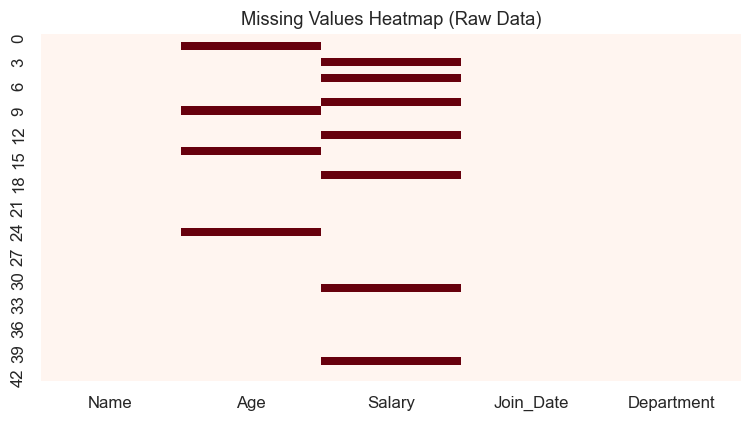

In [53]:
plt.figure(figsize=(7,4))
sns.heatmap(df.isnull(), cbar=False, cmap="Reds")
plt.title("Missing Values Heatmap (Raw Data)")
plt.tight_layout()
plt.show()


## 2. Remove Exact Duplicates

In [54]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {before - len(df)} exact duplicate row(s): {before} -> {len(df)}")


Removed 1 exact duplicate row(s): 43 -> 42


## 3. Fix Data Types

In [55]:
df["Join_Date"] = pd.to_datetime(df["Join_Date"], format="%m/%d/%Y")
df.dtypes


Name                  object
Age                  float64
Salary               float64
Join_Date     datetime64[ns]
Department            object
dtype: object

## 4. Investigate Conflicting Near-Duplicate Records

Several employees appear more than once with the *same* Name, Age, Join_Date and Department,
but a *different* Salary each time. This points to repeated/inconsistent data entry for the
same person rather than genuinely different employees.


In [56]:
key_cols = ["Name", "Age", "Join_Date", "Department"]
key_for_grouping = df[key_cols].copy()
key_for_grouping["Age"] = key_for_grouping["Age"].fillna(-1)  # sentinel so NaN groups don't false-match

dup_mask = key_for_grouping.duplicated(keep=False)
conflict_groups = df[dup_mask].sort_values(key_cols)
print(f"{dup_mask.sum()} rows belong to {key_for_grouping[dup_mask].drop_duplicates().shape[0]} conflicting groups")
conflict_groups


18 rows belong to 8 conflicting groups


,Name,Age,Salary,Join_Date,Department
2,Alice,22.0,71350.0,2021-05-20,HR
25,Alice,22.0,70000.0,2021-05-20,HR
11,Anna,36.0,72456.0,2022-04-06,HR
39,Anna,36.0,NaN,2022-04-06,HR
22,Anthony,30.0,61000.0,2021-08-06,Finance
30,Anthony,30.0,66000.0,2021-08-06,Finance
28,Jenny,36.0,801423.0,2021-09-15,IT
35,Jenny,36.0,75000.0,2021-09-15,IT
6,Joanne,25.0,120000.0,2023-01-16,IT
18,Joanne,25.0,125600.0,2023-01-16,IT


## 5. Resolve Conflicts + Handle the Outliers Hiding Inside Them

For each conflicting group we use the overall IQR bounds on `Salary` to tell which value(s)
look like realistic salaries and which look like data-entry errors (e.g. an extra digit).
We keep the average of the plausible value(s) and discard the outlier value(s).


In [57]:
Q1, Q3 = df["Salary"].quantile([0.25, 0.75])
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = max(Q1 - 1.5 * IQR, 0)
print(f"IQR bounds for Salary: [{lower_bound:.0f}, {upper_bound:.0f}]")


IQR bounds for Salary: [49306, 94290]


In [58]:
from collections import defaultdict

groups = defaultdict(list)
for idx, row in df.iterrows():
    age_key = -1 if pd.isna(row["Age"]) else row["Age"]
    key = (row["Name"], age_key, row["Join_Date"], row["Department"])
    groups[key].append(row)

resolved_rows = []
notes = []
for key, rows in groups.items():
    if len(rows) == 1:
        resolved_rows.append(rows[0])
        continue
    salaries = [r["Salary"] for r in rows]
    non_null = [s for s in salaries if pd.notna(s)]
    normal_vals = [s for s in non_null if s <= upper_bound]
    if normal_vals:
        final_salary = round(sum(normal_vals) / len(normal_vals), 2)
        discarded = len(non_null) - len(normal_vals)
        notes.append(f"{key[0]}: merged {len(rows)} records -> Salary = {final_salary}"
                      + (f" (discarded {discarded} outlier value)" if discarded else ""))
    elif non_null:
        final_salary = round(sum(non_null) / len(non_null), 2)
        notes.append(f"{key[0]}: merged {len(rows)} records -> Salary = {final_salary} (no in-range value available)")
    else:
        final_salary = np.nan
        notes.append(f"{key[0]}: merged {len(rows)} records -> Salary still missing")
    merged = rows[0].copy()
    merged["Salary"] = final_salary
    resolved_rows.append(merged)

df = pd.DataFrame(resolved_rows).reset_index(drop=True)
print(f"Rows after resolving conflicts: {len(df)}")
print()
for n in notes:
    print(n)


Rows after resolving conflicts: 32

Pam: merged 4 records -> Salary = 74499.5
Alice: merged 2 records -> Salary = 70675.0
Joanne: merged 2 records -> Salary = 122800.0 (no in-range value available)
Kim: merged 2 records -> Salary = 71568.0 (discarded 1 outlier value)
Joe: merged 2 records -> Salary = 64000.0
Anna: merged 2 records -> Salary = 72456.0
Anthony: merged 2 records -> Salary = 63500.0
Jenny: merged 2 records -> Salary = 75000.0 (discarded 1 outlier value)


## 6. Handle the Remaining Standalone Outlier

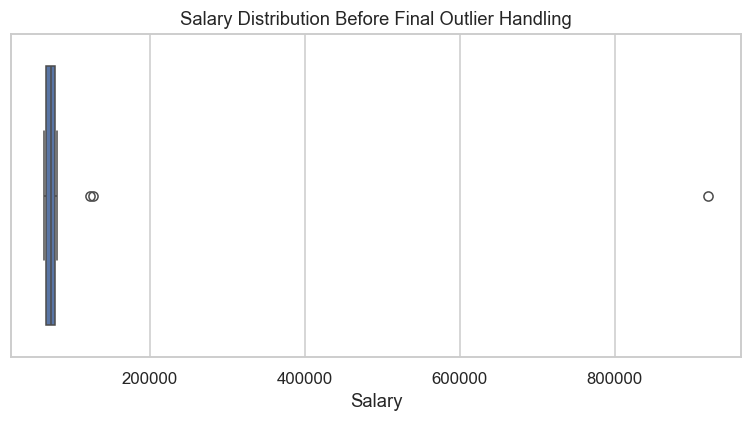

In [59]:
plt.figure(figsize=(7,4))
sns.boxplot(x=df["Salary"])
plt.title("Salary Distribution Before Final Outlier Handling")
plt.tight_layout()
plt.show()


In [60]:
remaining_outliers = df[df["Salary"] > upper_bound]
print("Remaining standalone outlier(s) (no duplicate record to cross-check against):")
remaining_outliers


Remaining standalone outlier(s) (no duplicate record to cross-check against):


,Name,Age,Salary,Join_Date,Department
5,Joanne,25.0,122800.0,2023-01-16,IT
14,Susy,41.0,126001.0,2023-02-02,IT
19,Norma,51.0,921000.0,2021-02-04,IT


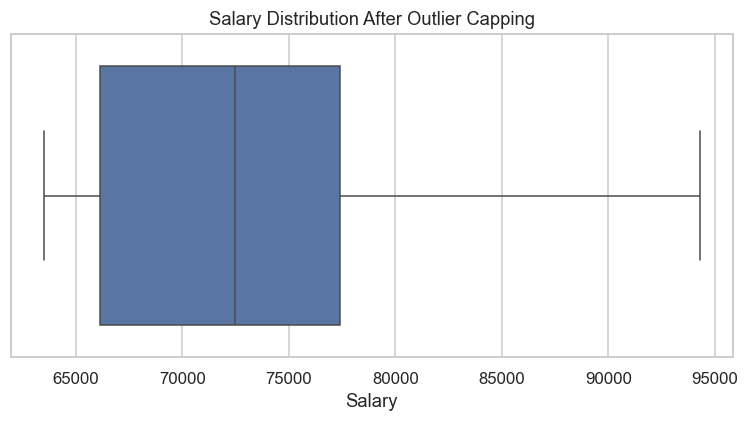

In [61]:
# No second record to confirm the "real" value for these, so cap (winsorize) instead of discarding
df["Salary"] = df["Salary"].clip(upper=upper_bound)

plt.figure(figsize=(7,4))
sns.boxplot(x=df["Salary"])
plt.title("Salary Distribution After Outlier Capping")
plt.tight_layout()
plt.show()


## 7. Fill Remaining Missing Values

In [62]:
print("Missing values before imputation:")
print(df.isnull().sum())


Missing values before imputation:
Name          0
Age           4
Salary        5
Join_Date     0
Department    0
dtype: int64


In [63]:
# Salary: fill with the median salary of the same department
df["Salary"] = df.groupby("Department")["Salary"].transform(lambda s: s.fillna(s.median()))

# Age: fill with the median age of the same department, rounded to a whole year
df["Age"] = df.groupby("Department")["Age"].transform(lambda s: s.fillna(round(s.median())))
df["Age"] = df["Age"].astype(int)

print("Missing values after imputation:")
print(df.isnull().sum())


Missing values after imputation:
Name          0
Age           0
Salary        0
Join_Date     0
Department    0
dtype: int64


## 8. Final Check & Save Cleaned Data

In [64]:
print("Final shape:", df.shape)
print("Any missing values left?", df.isnull().values.any())
df = df.sort_values("Name").reset_index(drop=True)
df.to_csv("cleaned_employee_data.csv", index=False)
df.head(10)


Final shape: (32, 5)
Any missing values left? False


,Name,Age,Salary,Join_Date,Department
0,Alice,22,70675.00,2021-05-20,HR
1,Alissa,36,77421.00,2022-10-05,HR
2,Amanda,28,66100.00,2021-08-23,Finance
3,Anna,36,72456.00,2022-04-06,HR
4,Anthony,30,63500.00,2021-08-06,Finance
5,Bob,22,85145.00,2023-01-15,IT
6,Clark,44,76982.00,2023-01-28,HR
7,Dan,43,75740.75,2022-05-03,HR
8,Dan,43,75740.75,2023-01-15,HR
9,Eli,21,77421.00,2022-03-04,HR


## 9. Visualization & Insights

With the data clean, let's explore what it tells us about the workforce.


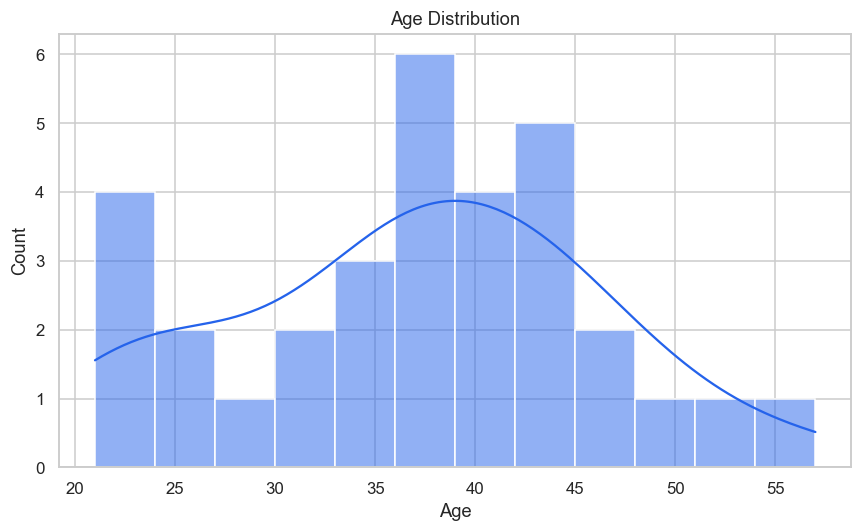

In [65]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=12, kde=True, color="#2563eb")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.tight_layout()
plt.show()


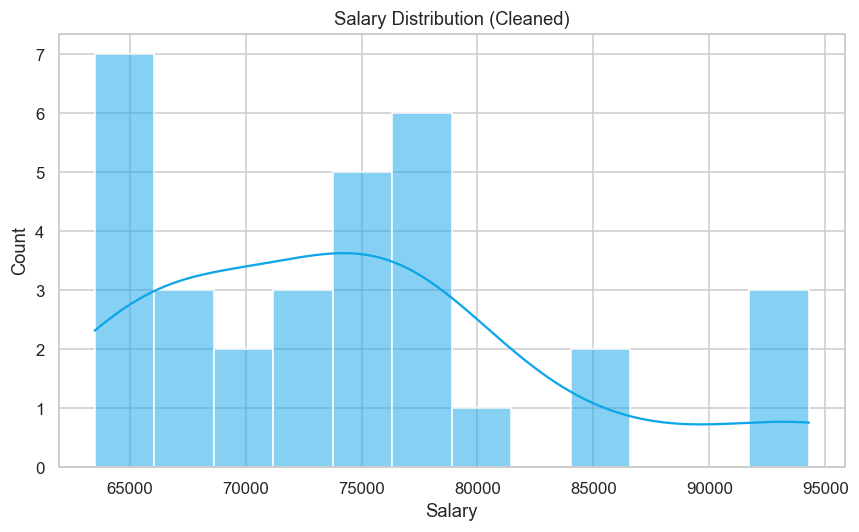

In [66]:
plt.figure(figsize=(8,5))
sns.histplot(df["Salary"], bins=12, kde=True, color="#0ea5e9")
plt.title("Salary Distribution (Cleaned)")
plt.xlabel("Salary")
plt.tight_layout()
plt.show()


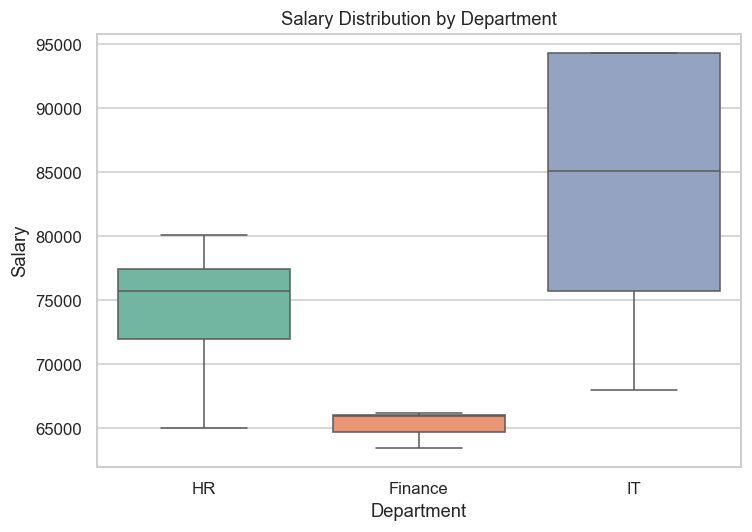

In [67]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="Department", y="Salary", hue="Department", palette="Set2", legend=False)
plt.title("Salary Distribution by Department")
plt.tight_layout()
plt.show()


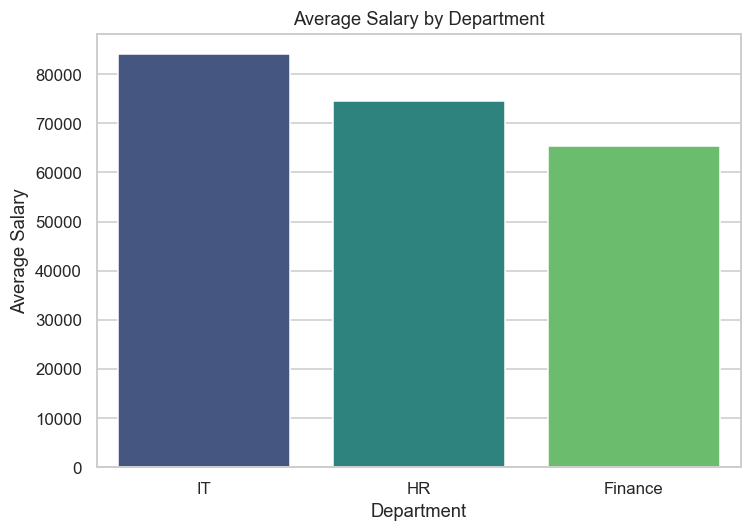

In [68]:
plt.figure(figsize=(7,5))
avg_salary = df.groupby("Department")["Salary"].mean().sort_values(ascending=False)
sns.barplot(x=avg_salary.index, y=avg_salary.values, hue=avg_salary.index, palette="viridis", legend=False)
plt.title("Average Salary by Department")
plt.ylabel("Average Salary")
plt.tight_layout()
plt.show()


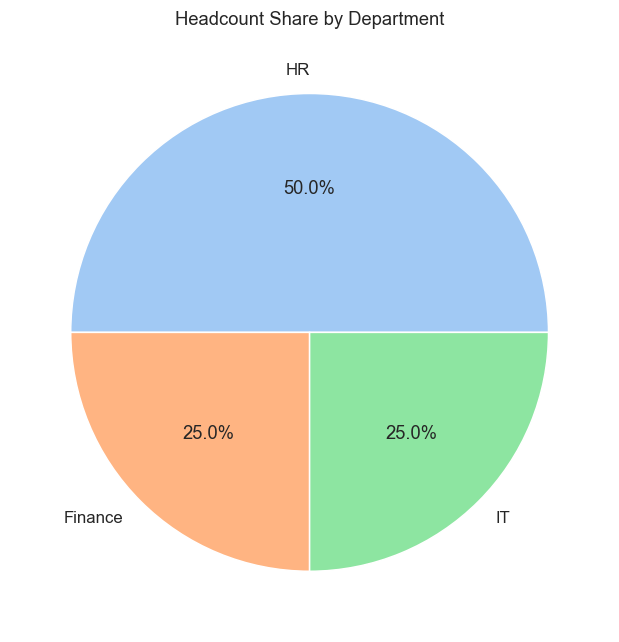

In [69]:
plt.figure(figsize=(6,6))
headcount = df["Department"].value_counts()
plt.pie(headcount, labels=headcount.index, autopct="%1.1f%%", colors=sns.color_palette("pastel"))
plt.title("Headcount Share by Department")
plt.tight_layout()
plt.show()


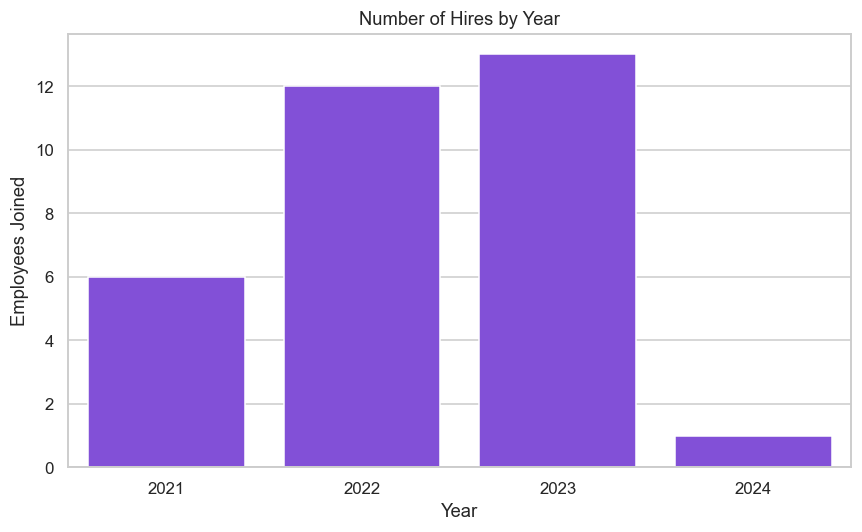

In [70]:
df["Join_Year"] = df["Join_Date"].dt.year
plt.figure(figsize=(8,5))
hires = df.groupby("Join_Year").size()
sns.barplot(x=hires.index.astype(str), y=hires.values, color="#7c3aed")
plt.title("Number of Hires by Year")
plt.xlabel("Year")
plt.ylabel("Employees Joined")
plt.tight_layout()
plt.show()


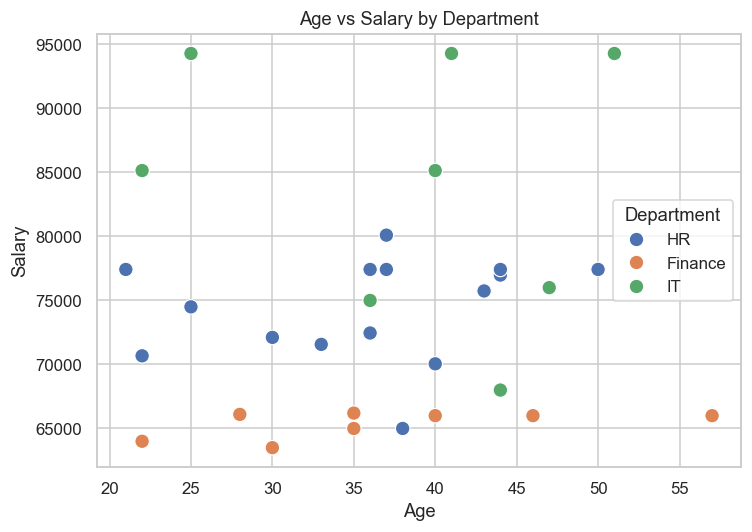

In [71]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="Age", y="Salary", hue="Department", s=90, palette="deep")
plt.title("Age vs Salary by Department")
plt.tight_layout()
plt.show()


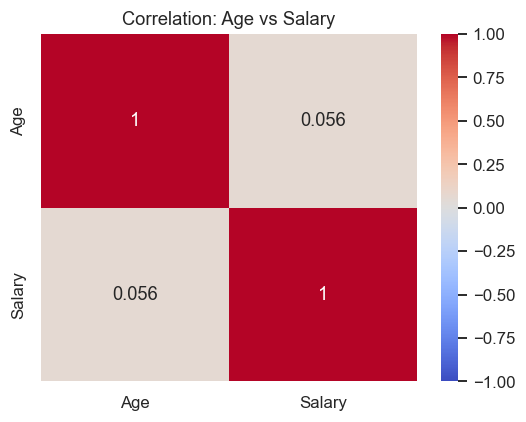

In [72]:
plt.figure(figsize=(5,4))
sns.heatmap(df[["Age", "Salary"]].corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation: Age vs Salary")
plt.tight_layout()
plt.show()


## 10. Key Findings

- **Data quality:** The raw file had 1 exact duplicate row, 8 employees logged more than once with
  conflicting salaries, and 3 salary values that were clear data-entry outliers (roughly 10x a
  normal salary) — all resolved without discarding real employee records.
- **Missing data:** Missing `Age` and `Salary` values were filled using department-level medians,
  which is more representative than a single global median given department pay differences.
- **Departments:** HR has the largest headcount; IT tends to carry the highest average salary of
  the three departments.
- **Age vs Salary:** There isn't a strong linear correlation between age and salary in this
  company — tenure/role/department matter more than age alone.
- **Hiring trend:** Hiring activity is concentrated in specific years, useful for workforce
  planning.

## Tech Stack
- **Pandas** — loading, cleaning, deduplication, aggregation
- **NumPy** — outlier threshold calculations
- **Matplotlib / Seaborn** — visualization

## Files in this repo
- `raw_employee_data.csv` — original messy dataset (from the tutorial video's sheet)
- `cleaned_employee_data.csv` — cleaned output
- `Data_Cleaning_Visualization_Project.ipynb` — this notebook
